# Mid-term project: Rental Price prediction
## Author: Yuxiang MA
## Date: 2025-10-23
## Version: 1.0

### 包的调用和数据录入

In [342]:
# 基础包
import pandas as pd, numpy as np
import re
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error

In [343]:
# 读入
test = pd.read_csv('ruc_Class25Q2_test_rent.csv')

# 去除列名中的所有空格
test.columns = [col.replace(" ", "") for col in test.columns]

### 数据清洗中

In [344]:
# 去除单位，并且将非区间数据的转化为数字

# 需要清洗的列 "面积", "套内面积", "房屋总数", "楼栋总数", "绿化率", "物业费", "燃气费", "供热费"
test['面积'] = test['面积'].str.replace('㎡', '', regex=False)
test['面积'] = test['面积'].astype(float)

test['房屋总数'] = test['房屋总数'].str.replace('户', '', regex=False)
test['房屋总数'] = test['房屋总数'].astype(float)

test['楼栋总数'] = test['楼栋总数'].str.replace('栋', '', regex=False)
test['楼栋总数'] = test['楼栋总数'].astype(float)

test['绿化率'] = test['绿化率'].str.replace('%', '', regex=False)
test['绿化率'] = test['绿化率'].astype(float)

# 存在-的区间
test['物业费'] = test['物业费'].str.replace('元/月/㎡', '', regex=False)
test['燃气费'] = test['燃气费'].str.replace('元/m³', '', regex=False)
test['供热费'] = test['供热费'].str.replace('元/㎡', '', regex=False)

test.sample(10)

,ID,城市,户型,装修,楼层,面积,朝向,交易时间,付款方式,租赁方式,...,供水,供暖,供电,燃气费,供热费,停车位,停车费用,coord_x,coord_y,客户反馈
1257,2001257,2,1室1厅1卫,精装修,高楼层/19层,48.82,南,2025-06-19,季付价,整租,...,商水/民水,NaN,商电,1.98,1,6000.0,350,107.582829,30.416932,合同霸王条款，卧室面积一般，印象中，社区氛围好
6511,2006511,4,2室0厅1卫,NaN,中楼层/11层,57.15,南,2025-09-02,季付价,整租,...,民水,集中供暖/自采暖,民电,3,NaN,2004.0,地上150 地下350,122.509443,32.329666,配套先进，通风好
183,2000183,10,2室1厅2卫,精装修,高楼层/34层,64.00,南,2025-03-20,月付价,整租,...,商水,NaN,商电,3-3.45,NaN,6498.0,40,114.580646,23.805294,有种感觉，天花板渗水，总体还不错，小区乱停乱放
801,2000801,2,2室2厅1卫,精装修,中楼层/33层,97.15,南,2025-04-12,季付价,整租,...,民水,NaN,民电,2,1,1100.0,400,107.528204,30.523554,我个人认为，交通便捷，总体上看，空气清新
5719,2005719,10,2室1厅1卫,精装修,中楼层/9层,70.00,南 北,2025-07-08,月付价,整租,...,民水,NaN,民电,3.45,NaN,NaN,NaN,114.354741,24.155581,干净，噪音可接受，客观上看，格局常见
9449,2009449,3,2室2厅1卫,精装修,中楼层/6层,30.00,南,2025-08-26,季付价,合租,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122.139186,32.312551,电梯停用频繁，设施损坏
7334,2007334,4,2室1厅1卫,NaN,高楼层/6层,47.00,南 北,2025-02-21,季付价,整租,...,民水,NaN,民电,3,NaN,254.0,暂无,122.496981,32.292575,说来也是，采光极佳，个人觉得，骑行方便，地面平整
4876,2004876,2,2室2厅1卫,精装修,低楼层/27层,79.50,东,2025-03-24,季付价,整租,...,民水,NaN,民电,1.97,NaN,1984.0,450,107.571181,30.358152,换句话说，宽带可接入，空气质量差
8566,2008566,4,2室2厅1卫,精装修,高楼层/20层,75.00,南,2025-03-12,季付价,整租,...,民水,自采暖,民电,3,NaN,NaN,160,122.652300,32.094368,总结一下，地板材质标准，客观上看，维护及时
2735,2002735,1,1室1厅1卫,精装修,高楼层/9层,62.44,南,2025-05-01,NaN,整租,...,商水/民水,自采暖,商电/民电,2.46,21,500.0,180,117.865941,40.932800,街区混乱，说句实话，窗外噪声多


### 将一些数值数据进行拆分，转化为数字

In [345]:
# (1)户型
# 定义一个函数解析户型
print(test['户型'].value_counts()) # 208类，室厅，室厅卫，居室（全部换成室），房间（换成室），未知（换成0），.（换成NULL），车库

户型
2室1厅1卫    2046
1室1厅1卫    1673
3室2厅2卫    1279
2室2厅1卫    1051
3室2厅1卫     912
          ... 
6室3厅2卫       1
5室2厅5卫       1
3室0厅0卫       1
7房间2卫        1
4室4厅4卫       1
Name: count, Length: 97, dtype: int64


In [346]:
test['户型'] = test['户型'].replace({
    '居室': '室', 
    '房间': '室', 
    '未知': '0', 
    '.': '0室0厅0卫'
})


In [347]:
import pandas as pd
import re

# Function to extract the number of rooms, living rooms, and bathrooms
def extract_features(huxing):
    # Ensure the input is a string and handle NaN or non-string values
    huxing = str(huxing) if pd.notna(huxing) else ""
    
    # Use regex to find all the numbers for '室', '厅', and '卫'
    rooms = re.findall(r'(\d+)室', huxing)
    halls = re.findall(r'(\d+)厅', huxing)
    baths = re.findall(r'(\d+)卫', huxing)
    
    # Assign default values if not found
    rooms = int(rooms[0]) if rooms else 0
    halls = int(halls[0]) if halls else 0
    baths = int(baths[0]) if baths else 0
    
    return rooms, halls, baths

# Apply the function to create new columns
test[['户型_室', '户型_厅', '户型_卫']] = test['户型'].apply(lambda x: pd.Series(extract_features(x)))


In [348]:

# Display the transformed DataFrame
print(test[['户型', '户型_室', '户型_厅', '户型_卫']].sample(10))


          户型  户型_室  户型_厅  户型_卫
4706  1室1厅1卫     1     1     1
7882  1室0厅1卫     1     0     1
7381  2室1厅1卫     2     1     1
2150  2室1厅1卫     2     1     1
5542  3室2厅1卫     3     2     1
8419  3室2厅2卫     3     2     2
2621  3室2厅2卫     3     2     2
5282  4室2厅2卫     4     2     2
5536   3房间2卫     0     0     2
6191  2室2厅1卫     2     2     1


In [349]:
# (2)拆分为：相对位置，总共楼层（可能有0值）
print(test['楼层'].value_counts()) # 258类，高中低楼层，顶层，底层，地下室，地下室（共0层）174个

楼层
高楼层/6层     508
中楼层/6层     327
高楼层/18层    239
低楼层/6层     226
低楼层/18层    219
          ... 
10/46层       1
19/37层       1
21/31层       1
22/31层       1
19/42层       1
Name: count, Length: 627, dtype: int64


In [350]:
# 提取相对楼层（/前面的部分）和总楼层（/后面的数字）
test['相对楼层'] = test['楼层'].str.split('/').str[0]  # /前面的部分

# 提取总楼层后面的数字部分，并确保是整数
test['总共楼层'] = test['楼层'].str.split('/').str[1].str.extract('(\d+)')
# 处理总楼层的 NaN 值并转化为整数
test['总共楼层'] = pd.to_numeric(test['总共楼层'], errors='coerce').fillna(0).astype(int)

print(test['相对楼层'].value_counts())

相对楼层
中楼层    3129
高楼层    2780
低楼层    2380
6       157
5       153
4       138
3       129
2        96
7        77
1        69
8        57
9        56
11       46
12       45
10       43
地下室      40
13       38
15       37
17       32
19       31
16       31
14       29
20       20
18       19
22       18
21       18
24       18
26       13
23       11
32        9
27        9
25        9
29        8
31        7
28        5
30        4
33        4
34        3
43        1
37        1
39        1
42        1
41        1
Name: count, dtype: int64


In [351]:
import pandas as pd

# 假设 test 是你的 DataFrame
def categorize_relative_floor(row):
    # 先检查相对楼层是否是字符串类型
    if isinstance(row['相对楼层'], str):
        # 如果是地下室相关楼层
        if '地下' in row['相对楼层']:
            return '地下室'
    
    # 如果是高楼层、中楼层或低楼层，直接使用原来的分类
    if row['相对楼层'] in ['高楼层', '中楼层', '低楼层']:
        return row['相对楼层']
    
    # 如果是数字类型的楼层
    try:
        floor_num = int(row['相对楼层'])
    except ValueError:
        return '其他'  # 如果不是数字类型，就归为“其他”
    
    # 获取总楼层数
    total_floors = row['总共楼层']
    
    # 设定楼层分类的标准
    if floor_num >= total_floors * 2/3:  # 高楼层，例如高于总楼层的75%
        return '高楼层'
    elif floor_num <= total_floors * 1/3:  # 低楼层，例如低于总楼层的25%
        return '低楼层'
    else:
        return '中楼层'  # 其他的为中楼层

# 使用 apply 来为每一行添加新的一列“楼层分类”
test['楼层分类'] = test.apply(categorize_relative_floor, axis=1)


In [352]:
# 查看结果
print(test[['相对楼层', '楼层分类', '总共楼层']].sample(10))

     相对楼层 楼层分类  总共楼层
9596    5  低楼层    24
9155  低楼层  低楼层    26
5432  中楼层  中楼层     6
7005  中楼层  中楼层    27
7758  高楼层  高楼层    33
2531  高楼层  高楼层     6
524   低楼层  低楼层    14
546   低楼层  低楼层     7
6811  中楼层  中楼层    33
8159  高楼层  高楼层    42


In [353]:
# 使用 pd.get_dummies() 进行 One-Hot Encoding
test_onehot = pd.get_dummies(test, columns=['楼层分类'], prefix='楼层')
test = pd.concat([test, test_onehot[['楼层_高楼层', '楼层_中楼层', '楼层_低楼层', '楼层_地下室']]], axis=1)

# 查看结果
print(test[['楼层分类','楼层_高楼层', '楼层_中楼层', '楼层_低楼层', '楼层_地下室']].sample(10))

     楼层分类  楼层_高楼层  楼层_中楼层  楼层_低楼层  楼层_地下室
4117  高楼层    True   False   False   False
5120  高楼层    True   False   False   False
2633  高楼层    True   False   False   False
674   高楼层    True   False   False   False
4700  高楼层    True   False   False   False
7797  中楼层   False    True   False   False
3386  低楼层   False   False    True   False
6191  中楼层   False    True   False   False
8366  低楼层   False   False    True   False
9087  高楼层    True   False   False   False


In [354]:
# 筛选相对楼层开头的列
floor_cols = [col for col in test.columns if col.startswith('相对楼层_')]

# 查看原始相对楼层 + 对应的 one-hot 列
test[['相对楼层'] + floor_cols].sample(10, random_state=111)

,相对楼层
3254,高楼层
5656,6
8523,15
8898,高楼层
1360,中楼层
1085,中楼层
7256,低楼层
6931,中楼层
4351,2
6066,低楼层


In [355]:
# (3)生成朝向的dummy
test['朝向'].value_counts() # 173类，有复合方向

朝向
南               4651
南 北             1759
东南               892
北                628
东                594
西南               301
西                265
东北               135
西北               116
东 西               88
东南 南              64
东 南               39
东 东南              29
南 西南              28
东 北               16
南 西               15
东南 北              13
南 西 北             13
东南 西南             12
西 北               11
西南 北              11
南 西北              10
东 南 北             10
东南 西北              9
西南 西               7
北 东北               6
东 东北               4
西南 东北              3
东南 东北              3
西 西北               3
东南 南 北             3
东南 南 西南            3
西北 北               3
东 东南 南             3
东 南 西              2
未知                 2
东 南 西 北            2
西 西北 北             2
东南 西               1
东 东南 南 北           1
南 西 西北             1
南 东北               1
西 北 东北             1
东 西南               1
东 南 西南             1
南 西南 北             1
东 东南 南 西南          1
东 西北      

In [356]:
import pandas as pd

# 创建一个函数来处理房屋朝向
def process_orientation(orientation):
    if pd.isna(orientation) or orientation == "未知":  # 如果是 NaN 或 "未知"
        return pd.Series([0, 0, 0, 0], index=['朝向_东', '朝向_南', '朝向_西', '朝向_北'])
    
    # 初始化四个方向的权重
    weights = {'东': 0, '南': 0, '西': 0, '北': 0}
    
    # 将方向拆分为列表
    directions = orientation.split()
    
    # 定义复合方向列表
    compound_directions = ['东南', '东北', '西南', '西北']
    
    # 遍历每个方向
    for direction in directions:
        # 处理复合方向，如 "东南"
        if direction in compound_directions:
            weights[direction[0]] += 0.5
            weights[direction[1]] += 0.5
        # 处理单一方向
        elif direction in weights:
            weights[direction] = 1
    
    # 确保每个方向的权重不超过1
    for direction in weights:
        weights[direction] = min(weights[direction], 1)
    
    return pd.Series([weights['东'], weights['南'], weights['西'], weights['北']], 
                    index=['朝向_东', '朝向_南', '朝向_西', '朝向_北'])

# 将"未知"的朝向值转换为NaN
test['朝向'] = test['朝向'].replace("未知", pd.NA)

# 应用到实际数据
orientation_df = test['朝向'].apply(process_orientation)

# 将处理结果与原始数据合并
test = pd.concat([test, orientation_df], axis=1)


In [357]:
# 查看处理后的数据
print(test[['朝向', '朝向_东', '朝向_南', '朝向_西', '朝向_北']].sample(10))
# 删除所有以 "朝向_" 开头的列
# columns_to_drop = [col for col in test.columns if col.startswith('楼型_')]
# test = test.drop(columns=columns_to_drop)

        朝向  朝向_东  朝向_南  朝向_西  朝向_北
2031     南   0.0   1.0   0.0   0.0
7188     南   0.0   1.0   0.0   0.0
2963     南   0.0   1.0   0.0   0.0
5926    东北   0.5   0.0   0.0   0.5
8131   南 北   0.0   1.0   0.0   1.0
2028     东   1.0   0.0   0.0   0.0
8245   南 北   0.0   1.0   0.0   1.0
9390  东南 南   0.5   1.0   0.0   0.0
839      南   0.0   1.0   0.0   0.0
920     东南   0.5   0.5   0.0   0.0


In [358]:
# (20)建筑结构
print(test['建筑结构'].value_counts()) # 15类

建筑结构
板楼               1800
塔楼               1591
塔楼/板楼/塔板结合        893
塔楼/板楼             861
塔板结合              714
板楼/塔板结合           588
塔楼/塔板结合           320
塔楼/板楼/塔板结合/平房      95
塔楼/板楼/平房           66
板楼/平房              65
塔楼/平房              41
板楼/塔板结合/平房         21
塔板结合/平房            13
平房                  6
Name: count, dtype: int64


In [359]:
# 步骤 1: 将 NaN 或其他非字符串值替换为空字符串
test.loc[:, '建筑结构'] = test['建筑结构'].fillna('')

# 步骤 2: 获取所有唯一的取值组合，并将它们用"/"连接
all_combinations = test['建筑结构'].unique()

# 步骤 3: 对每个组合，拆分为单个特征并生成虚拟变量
features_set = set()
for combination in all_combinations:
    if combination:  # 确保不为空
        features_set.update(combination.split('/'))

# 步骤 4: 为每个特征生成虚拟变量，虚拟变量名以'楼型_'开头
for feature in features_set:
    # 用apply处理，每个特征如果在建筑结构_comm中存在，则置为1，否则为0；如果原始值为空则为NaN
    test.loc[:, f'楼型_{feature}'] = test['建筑结构'].apply(
        lambda x: 1 if feature in x else (None if x == '' else 0)
    )

In [360]:
# 展示所有楼型开头的变量
print("\n生成的楼型特征列表：")
building_features = [col for col in test.columns if col.startswith('楼型_')]
print(building_features)
# 展示包含原始字段和新建特征的样本
print("\n特征数据样本：")
sample_cols = ['建筑结构', *building_features]
print(test[sample_cols].sample(10))  # 完全随机抽样


生成的楼型特征列表：
['楼型_塔楼', '楼型_塔板结合', '楼型_板楼', '楼型_平房']

特征数据样本：
            建筑结构  楼型_塔楼  楼型_塔板结合  楼型_板楼  楼型_平房
5856  塔楼/板楼/塔板结合    1.0      1.0    1.0    0.0
6677                NaN      NaN    NaN    NaN
9468                NaN      NaN    NaN    NaN
3339          塔楼    1.0      0.0    0.0    0.0
6605        塔板结合    0.0      1.0    0.0    0.0
1670                NaN      NaN    NaN    NaN
1029     板楼/塔板结合    0.0      1.0    1.0    0.0
409           塔楼    1.0      0.0    0.0    0.0
1838                NaN      NaN    NaN    NaN
2784  塔楼/板楼/塔板结合    1.0      1.0    1.0    0.0


In [361]:
# (5) 装修
test['装修'].value_counts() # 4类，精、简、毛坯、其他

装修
精装修    7091
Name: count, dtype: int64

In [362]:
# 创建一个新列"是否有装修"：如果"装修"列非空，则为1，否则为0
test['是否有装修'] = test['装修'].apply(lambda x: 1 if pd.notna(x) else 0)

In [363]:
# 查看结果
print(test[['装修', '是否有装修']].sample(10))

       装修  是否有装修
6796  精装修      1
9717  精装修      1
5505  NaN      0
59    精装修      1
5606  NaN      0
8029  精装修      1
7605  精装修      1
77    精装修      1
2135  精装修      1
4367  精装修      1


In [364]:
# (6)电梯
test['电梯'].value_counts() # 2

电梯
有    6496
无    3277
Name: count, dtype: int64

In [365]:
# 创建一个新列"电梯新值"：根据"电梯"列的值来设置新列的值
test['有无电梯'] = test['电梯'].apply(lambda x: 1 if x == '有' else (0 if x == '无' else pd.NA))

In [366]:
# 查看结果
print(test[['电梯', '有无电梯']].sample(10))

     电梯  有无电梯
9355  有     1
7554  有     1
2186  有     1
9569  有     1
5119  有     1
9347  有     1
2650  有     1
705   有     1
845   有     1
5562  有     1


In [367]:
# (8)交易时间
# 转换为 datetime 类型
test['交易时间'] = pd.to_datetime(test['交易时间'], errors='coerce')

In [368]:
# 提取年/月/日（保留缺失）
# 使用 .where(test['交易时间'].notna()) 确保当交易时间为 NaT/缺失时，新变量也为缺失
test['交易_年'] = test['交易时间'].dt.year.where(test['交易时间'].notna())
test['交易_月'] = test['交易时间'].dt.month.where(test['交易时间'].notna())
test['交易_日'] = test['交易时间'].dt.day.where(test['交易时间'].notna())

In [369]:
# test = test.loc[:, ~test.T.duplicated()]
# 显示交易时间相关的列
print("交易时间及其拆分后的年月日变量：")
print(test[['交易时间', '交易_年', '交易_月', '交易_日']].sample(10))

交易时间及其拆分后的年月日变量：
           交易时间  交易_年  交易_月  交易_日
9664 2025-04-28  2025     4    28
5019 2025-06-09  2025     6     9
7462 2025-03-14  2025     3    14
8148 2025-06-30  2025     6    30
3949 2025-07-10  2025     7    10
6526 2025-07-12  2025     7    12
509  2025-04-18  2025     4    18
322  2025-03-27  2025     3    27
8275 2025-03-18  2025     3    18
4482 2025-11-01  2025    11     1


In [370]:
# (14)物业类别
print(test['物业类别'].value_counts()) # 233类

物业类别
普通住宅                              2284
普通住宅/底商                            462
普通住宅/商业/底商                         392
车库/普通住宅/商业/底商                      337
普通住宅/商业                            319
                                  ... 
车库/普通住宅/写字楼/商业/工业厂房/底商/地下仓储/库房       1
普通住宅/商业/商住两用/商业办公类                   1
普通住宅/公寓/公寓/住宅/公寓/公寓                  1
普通住宅/花园洋房/新式里弄                       1
普通住宅/旧式里弄                            1
Name: count, Length: 185, dtype: int64


In [371]:
# 1. 获取所有物业类别组合
all_combinations = test['物业类别'].dropna().unique()
print("所有不同的物业类别组合数量：", len(all_combinations))

# 2. 提取所有独立的物业类别
unique_categories = set()
for combo in all_combinations:
    categories = combo.split('/')
    unique_categories.update(categories)

# 3. 按字母顺序排序并展示所有独立的物业类别
sorted_categories = sorted(unique_categories)
print("\n所有独立的物业类别（按字母排序）：")
for i, category in enumerate(sorted_categories, 1):
    print(f"{i}. {category}")

print(f"\n总共有 {len(sorted_categories)} 种独立的物业类别")

所有不同的物业类别组合数量： 185

所有独立的物业类别（按字母排序）：
1. 人防车位
2. 住宅
3. 住宅式公寓
4. 公寓
5. 公寓（住宅）
6. 写字楼
7. 别墅
8. 单身公寓（住宅）
9. 商业
10. 商业办公类
11. 商住两用
12. 商务公寓
13. 商务型公寓
14. 四合院
15. 地下仓储
16. 工业厂房
17. 平房
18. 库房
19. 底商
20. 新式里弄
21. 旧式里弄
22. 普通住宅
23. 老公寓
24. 花园洋房
25. 车库
26. 酒店式公寓

总共有 26 种独立的物业类别


In [372]:
# 创建进一步合并的映射字典
usage_mapping_further = {
    '普通住宅': '住宅',
    '商住两用': '住宅',
    '别墅': '住宅',
    '花园洋房': '住宅',
    '四合院': '住宅',  # 将四合院合并为住宅
    '新式里弄': '住宅',  # 将新式里弄合并为住宅
    '商业办公类': '商业',
    '车库': '车库',
    '公寓': '公寓',
    '商务公寓': '公寓',
    '酒店式公寓': '公寓',
    '商务型公寓': '公寓',
    '公寓（住宅）': '公寓',
    '住宅式公寓': '公寓',
    '老公寓': '公寓',
    '公寓/公寓': '公寓',
    '公寓/住宅': '公寓',
    '底商': '商业',
    '写字楼': '商业',
    '商业': '商业',
    '单身公寓（住宅）': '其他',
    '人防车位': '其他',
    '地下仓储': '其他',
    '工业厂房': '其他',
    '平房': '其他',
    '库房': '其他',
    '旧式里弄': '其他'
}

# 应用映射，创建新的标准化列
test['物业类别_进一步标准'] = test['物业类别'].map(usage_mapping_further)

# 查看合并后各类别的计数
test['物业类别_进一步标准'].value_counts()

物业类别_进一步标准
住宅    2296
商业       4
Name: count, dtype: int64

In [373]:
# (15)建筑年代
print(test['建筑年代'].value_counts()) # 736类，年份和时间段都有

建筑年代
2019年         99
2015-2018年    84
2008年         81
2000-2012年    77
2008-2014年    74
              ..
2007-2014年     1
1977-1978年     1
1979-1995年     1
1992-1999年     1
1977-2002年     1
Name: count, Length: 594, dtype: int64


In [374]:
# 处理建筑年代
def process_building_year(year_str):
    """处理建筑年代，返回中点年份和年代分类"""
    if pd.isna(year_str) or year_str == '未知':
        return pd.Series([None, None], 
                        index=['建筑年份', '建筑年代分类'])
    
    # 清理数据
    year_str = str(year_str).strip().replace('年', '')
    
    try:
        if '-' in year_str:
            # 处理年份范围，直接取中点
            start_year, end_year = map(int, year_str.split('-'))
            year = (start_year + end_year) // 2
        else:
            # 单一年份
            year = int(year_str)
        
        # 确定年代分类
        if year < 1970:
            decade = '1970年以前'
        elif year >= 2020:
            decade = '2020年及以后'
        else:
            # 1970-2019年按照每十年分类
            decade_start = (year // 10) * 10
            decade = f'{decade_start}年代'
            
        return pd.Series([year, decade],
                        index=['建筑年份', '建筑年代分类'])
    except:
        # 处理异常情况
        return pd.Series([None, None],
                        index=['建筑年份', '建筑年代分类'])

# 应用处理函数
year_data = test['建筑年代'].apply(process_building_year)
test[['建筑年份', '建筑年代分类']] = year_data

# 计算建筑物龄期（到交易时的年龄）
test['建筑物龄期'] = test.apply(
    lambda x: x['交易_年'] - x['建筑年份'] if pd.notna(x['交易_年']) and pd.notna(x['建筑年份']) else None,
    axis=1
)

In [375]:

# 展示处理结果
print("\n建筑年代分类分布：")
print(test['建筑年代分类'].value_counts())

print("\n建筑物龄期统计：")
print(test['建筑物龄期'].describe())

# 随机展示10个样本
print("\n随机10个样本的处理结果：")
sample_cols = ['建筑年代', '建筑年份', '建筑年代分类', '建筑物龄期']
print(test[sample_cols].sample(10))


建筑年代分类分布：
建筑年代分类
2010年代      2431
2000年代      2300
1990年代       989
1980年代       478
1970年代       102
2020年及以后      82
1970年以前       10
Name: count, dtype: int64

建筑物龄期统计：
count    6392.000000
mean       19.804130
std         9.962948
min         3.000000
25%        12.000000
50%        18.000000
75%        25.000000
max        68.000000
Name: 建筑物龄期, dtype: float64

随机10个样本的处理结果：
            建筑年代    建筑年份  建筑年代分类  建筑物龄期
380   1985-1993年  1989.0  1980年代   36.0
2721         NaN     NaN    None    NaN
1474         NaN     NaN    None    NaN
8000       2001年  2001.0  2000年代   24.0
9545         NaN     NaN    None    NaN
6929         NaN     NaN    None    NaN
3457  2008-2010年  2009.0  2000年代   16.0
5314  2005-2008年  2006.0  2000年代   19.0
8370         NaN     NaN    None    NaN
9237  2003-2013年  2008.0  2000年代   17.0


In [376]:
# (16)开发商——有鸡毛用

In [377]:
# (18)物业公司——有鸡毛用

In [378]:
# (19)物业费
print(test['物业费'].value_counts()) # 1032类

物业费
2.8         243
0.8         218
1           143
1.2         138
1.8         132
           ... 
0.88          1
1.29          1
3.8-3.85      1
11            1
1.5-1.7       1
Name: count, Length: 778, dtype: int64


In [379]:
# 处理函数
def process_property_fee(fee_str):
    # 如果 fee_str 是 float 类型或 None，转换为字符串并进行处理
    fee_str = str(fee_str).strip()  # 转换为字符串并去除两边空格
    
    # 如果是空字符串或无效值，返回默认值
    if not fee_str or '未知' in fee_str:
        return None, None, None  # 不需要跨度，只有最小、最大和中间值
    
    # 处理单一值
    if '-' not in fee_str:
        fee = float(fee_str)
        return fee, fee, fee  # 单一值的最小、最大值相等，中间值也相等

    # 处理范围值
    min_fee, max_fee = fee_str.split('-')
    min_fee = float(min_fee)
    max_fee = float(max_fee)
    mid_fee = (min_fee + max_fee) / 2  # 计算均值
    return min_fee, max_fee, mid_fee  # 返回最小值、最大值、中间值

# 处理物业费
test[['物业费_最小', '物业费_最大', '物业费_均值']] = test['物业费'].apply(lambda x: pd.Series(process_property_fee(x) if x else (None, None, None)))

In [380]:
# test = test.loc[:, ~test.T.duplicated()]
test[['物业费'] + ['物业费_最小'] + ['物业费_最大'] + ['物业费_均值']].sample(100)

,物业费,物业费_最小,物业费_最大,物业费_均值
3813,2.8,2.8,2.8,2.80
2860,NaN,NaN,NaN,NaN
884,NaN,NaN,NaN,NaN
1536,2,2.0,2.0,2.00
421,1.9-2.5,1.9,2.5,2.20
...,...,...,...,...
9606,0.5,0.5,0.5,0.50
1857,NaN,NaN,NaN,NaN
9512,1.2-1.3,1.2,1.3,1.25
9117,2.5,2.5,2.5,2.50


In [381]:
# (21)产权描述
print(test['产权描述'].value_counts()) # 165类

产权描述
商品房                        3684
商品房/使用权                     805
商品房/私产                      436
商品房/动迁安置房                   209
商品房/使用权/私产                  160
                           ... 
商品房/经济适用房/使用权/拆迁还建房/集资房       1
商品房/已购公房/二类经济适用房              1
商品房/房改房/使用权/私产/集资房/宅基房        1
商品房/房改房/经济适用房/拆迁还建房           1
商品房/经济适用房/私产/拆迁还建房/集资房        1
Name: count, Length: 130, dtype: int64


In [382]:
# # # # # 删除所有以 '产权_' 开头的特征列
# test.drop(columns=[col for col in test.columns if col.startswith('产权_')], inplace=True)
# # # test.sample(10, random_state=111)[['产权描述'] + [col for col in test.columns if col.startswith('产权_')]]
# # # # 将空字符串替换为缺失值 (NaN)
# # # # test['产权描述'] = test['产权描述'].replace('', np.nan)

In [383]:
# 步骤 1: 获取所有唯一的产权描述组合
all_combinations = test['产权描述'].dropna().unique()  # 去掉 NaN

# 步骤 2: 获取所有特征并拆分
features_set = set()
for combination in all_combinations:
    if isinstance(combination, str):  # 只处理字符串类型
        # 拆分描述组合并更新特征集
        features_set.update(combination.split('/'))

# 打印所有拆分出的特征（供检查）
print("所有唯一特征：", features_set)


所有唯一特征： {'拆迁还建房', '公租房', '回迁房', '廉租房', '定向安置房', '一类经济适用房', '宅基房', '军产', '私产', '自住型商品房', '商品房', '经济适用房', '房改房', '使用权', '乡产', '校产', '售后公房', '二类经济适用房', '安居型商品房', '限价商品房', '央产房', '集资房', '共有产权房', '已购公房', '动迁安置房'}


In [384]:
# 定义映射规则
merge_rules = {
    '商品房类': ['商品房', '自住型商品房', '限价商品房'],
    '经济适用房类': ['经济适用房', '一类经济适用房', '二类经济适用房'],
    '安置房类': ['拆迁还建房', '动迁安置房', '回迁房', '定向安置房'],
    '公房类': ['公租房', '廉租房', '售后公房', '集资房', '已购公房','房改房'],
    '私产类': ['私产', '军产', '央产房', '乡产', '校产'],
    '其他类': ['安居型商品房', '共有产权房', '使用权', '宅基房']
}

# 步骤 1: 根据合并规则创建新列
def apply_merge_rules(df, merge_rules):
    # 为每个大类创建新列
    for category, keywords in merge_rules.items():
        # 初始化该分类列，所有行默认为 0
        df[f'产权_{category}'] = 0

        # 遍历每行产权描述
        for idx, row in df.iterrows():
            # 如果产权描述不是空值
            if isinstance(row['产权描述'], str):
                # 拆分产权描述（按 / 拆分）
                features = set(row['产权描述'].split('/'))

                # 检查是否有关键词出现在拆分后的特征中
                if any(keyword in features for keyword in keywords):
                    df.at[idx, f'产权_{category}'] = 1  # 如果匹配，标记为 1

    return df

# 执行操作
test = apply_merge_rules(test, merge_rules)

In [385]:
# 输出查看结果，确保只有6列
test.sample(10)[['产权描述'] + [col for col in test.columns if col.startswith('产权_')]]

,产权描述,产权_商品房类,产权_经济适用房类,产权_安置房类,产权_公房类,产权_私产类,产权_其他类
2266,商品房,1,0,0,0,0,0
2321,商品房,1,0,0,0,0,0
4199,NaN,0,0,0,0,0,0
409,商品房,1,0,0,0,0,0
1055,商品房,1,0,0,0,0,0
1357,商品房,1,0,0,0,0,0
7492,商品房,1,0,0,0,0,0
7703,商品房/使用权,1,0,0,0,0,1
5576,商品房/私产,1,0,0,0,1,0
18,NaN,0,0,0,0,0,0


In [386]:
# (22) 供水
print(test['供水'].value_counts()) # 3类，民商

供水
民水       4313
商水/民水    2410
商水        288
Name: count, dtype: int64


In [387]:
# 先生成哑变量
dummies = pd.get_dummies(test['供水'], prefix='供水')

# 再用 where() 保留缺失：如果原列是 NaN，对应新列也变 NaN
dummies = dummies.where(test['供水'].notna(), np.nan)

# 合并回原数据
test = pd.concat([test, dummies], axis=1)

In [388]:
# 随机显示 10 行，只选出指定列
cols = [c for c in test.columns if c.startswith('供水')]
test.loc[:, cols].sample(10)

,供水,供水_商水,供水_商水/民水,供水_民水
2046,NaN,NaN,NaN,NaN
4399,NaN,NaN,NaN,NaN
5475,民水,False,False,True
1313,NaN,NaN,NaN,NaN
1347,民水,False,False,True
2411,商水/民水,False,True,False
2436,NaN,NaN,NaN,NaN
5319,商水,True,False,False
343,NaN,NaN,NaN,NaN
1930,NaN,NaN,NaN,NaN


In [389]:
# (23) 供暖
print(test['供暖'].value_counts()) # 总的来说，3类

供暖
集中供暖            1706
自采暖             1329
集中供暖/自采暖         381
无供暖              132
集中供暖/自采暖/无供暖      16
自采暖/无供暖           14
Name: count, dtype: int64


In [390]:
# 基本类别（可以从数据中提取唯一值的拆分后集合）
base_types = ['集中供暖', '自采暖', '无供暖']

# 创建空列
for t in base_types:
    test[t] = np.nan  # 先设为空，便于保留缺失

# 遍历每一行
for i, val in test['供暖'].items():
    if pd.isna(val):
        continue  # 缺失保留为 NaN
    types = val.split('/')  # 按 "/" 拆分
    weight = 1 / len(types)  # 平均分配权重
    for t in types:
        test.loc[i, t] = weight  # 填充权重

test = test.rename(columns={t: f'供暖_{t}' for t in base_types})

In [391]:
# 随机显示 10 行，只选出指定列
cols = [c for c in test.columns if c.startswith('供暖')]
test.loc[:, cols].sample(10)

,供暖,供暖_集中供暖,供暖_自采暖,供暖_无供暖
7958,集中供暖,1.0,NaN,NaN
1177,NaN,NaN,NaN,NaN
7800,集中供暖,1.0,NaN,NaN
6817,自采暖,NaN,1.0,NaN
1881,NaN,NaN,NaN,NaN
2451,NaN,NaN,NaN,NaN
6894,NaN,NaN,NaN,NaN
3243,NaN,NaN,NaN,NaN
5103,NaN,NaN,NaN,NaN
2835,NaN,NaN,NaN,NaN


In [392]:
# (24) 供电
print(test['供电'].value_counts()) # 

供电
民电       4181
商电/民电    2549
商电        283
Name: count, dtype: int64


In [393]:
# 先生成哑变量
dummies = pd.get_dummies(test['供电'], prefix='供电')

# 再用 where() 保留缺失：如果原列是 NaN，对应新列也变 NaN
dummies = dummies.where(test['供电'].notna(), np.nan)

# 合并回原数据
test = pd.concat([test, dummies], axis=1)

In [394]:
# 随机显示 10 行，只选出指定列
cols = [c for c in test.columns if c.startswith('供电')]
test.loc[:, cols].sample(10)

,供电,供电_商电,供电_商电/民电,供电_民电
8219,商电/民电,False,True,False
1751,民电,False,False,True
1561,商电/民电,False,True,False
891,商电/民电,False,True,False
9672,民电,False,False,True
8623,商电/民电,False,True,False
8539,NaN,NaN,NaN,NaN
6934,商电/民电,False,True,False
9772,民电,False,False,True
5140,NaN,NaN,NaN,NaN


In [395]:
# (25) 燃气费
test['燃气费'].value_counts() # 只有数字和范围，以及空值

燃气费
2.61        1285
3            924
3.45         861
3.5          647
1.98         305
            ... 
2.7-5          1
3.46           1
0.5-3.3        1
2.3-3.95       1
2.9-3.95       1
Name: count, Length: 188, dtype: int64

In [396]:
# 定义通用费用处理函数
def process_fee(fee_str):
    """
    输入：单个燃气费字符串（可能是'2.5'、'2.5-3.0'或空值）
    输出：最小值、最大值、均值
    """
    if pd.isna(fee_str):
        return None, None, None
    
    fee_str = str(fee_str).strip()
    
    try:
        # 单一数值
        if '-' not in fee_str:
            fee = float(fee_str)
            return fee, fee, fee
        
        # 区间值：如 '1.73-1.75'
        parts = fee_str.split('-')
        if len(parts) == 2:
            min_fee = float(parts[0])
            max_fee = float(parts[1])
        else:
            # 处理异常格式（例如 '1.8-1.98-2.1'）时，只取前两个
            min_fee, max_fee = float(parts[0]), float(parts[1])
        mid_fee = (min_fee + max_fee) / 2
        return min_fee, max_fee, mid_fee
    except Exception:
        return None, None, None

# 应用于燃气费字段
test[['燃气费_最小', '燃气费_最大', '燃气费_均值']] = (
    test['燃气费']
    .apply(lambda x: pd.Series(process_fee(x)))
)

In [397]:
# test = test.loc[:, ~test.T.duplicated()]
test[['燃气费'] + ['燃气费_最小'] + ['燃气费_最大'] + ['燃气费_均值']].sample(100)

,燃气费,燃气费_最小,燃气费_最大,燃气费_均值
219,2.61,2.61,2.61,2.610
1191,2,2.00,2.00,2.000
353,1.98,1.98,1.98,1.980
2942,NaN,NaN,NaN,NaN
5485,NaN,NaN,NaN,NaN
...,...,...,...,...
8798,NaN,NaN,NaN,NaN
3773,2.61,2.61,2.61,2.610
1983,2.61,2.61,2.61,2.610
101,2.4-2.75,2.40,2.75,2.575


In [398]:
# (26) 供热费
test['供热费'].value_counts() # 数字、范围

供热费
30           814
1            339
24           165
24-30        154
22           154
            ... 
4.91           1
10             1
0.1-1          1
2.58-5.88      1
29.9-30        1
Name: count, Length: 98, dtype: int64

In [399]:
# 通用费用处理函数
def process_fee(fee_str):
    """
    输入：单个费用字符串（可能是 '30'、'24-30'、'未知'、None 等）
    输出：最小值、最大值、均值
    """
    if pd.isna(fee_str):
        return None, None, None
    
    fee_str = str(fee_str).strip()
    
    if not fee_str or '未知' in fee_str:
        return None, None, None

    try:
        # 单值情况
        if '-' not in fee_str:
            fee = float(fee_str)
            return fee, fee, fee
        
        # 区间情况，如 '24-30'
        parts = fee_str.split('-')
        if len(parts) == 2:
            min_fee = float(parts[0])
            max_fee = float(parts[1])
        else:
            # 若区间异常（如 '2.4-20-30'），取前两个
            min_fee, max_fee = float(parts[0]), float(parts[1])
        mid_fee = (min_fee + max_fee) / 2
        return min_fee, max_fee, mid_fee
    except Exception:
        return None, None, None


# === 对 “供热费” 列进行处理 ===
test[['供热费_最小', '供热费_最大', '供热费_均值']] = (
    test['供热费']
    .apply(lambda x: pd.Series(process_fee(x)))
)

In [400]:
print(test[['供热费', '供热费_最小', '供热费_最大', '供热费_均值']].sample(10))

        供热费  供热费_最小  供热费_最大  供热费_均值
285      30    30.0    30.0    30.0
3398    NaN     NaN     NaN     NaN
8927    NaN     NaN     NaN     NaN
8506    NaN     NaN     NaN     NaN
2071    NaN     NaN     NaN     NaN
3943    NaN     NaN     NaN     NaN
7684  24-30    24.0    30.0    27.0
1604     30    30.0    30.0    30.0
3681    NaN     NaN     NaN     NaN
6934    NaN     NaN     NaN     NaN


In [401]:
# (27) 停车位
print(test['停车位'].value_counts()) # 

停车位
500.0     252
200.0     222
300.0     215
1000.0    161
100.0     134
         ... 
868.0       1
483.0       1
8.0         1
13.0        1
496.0       1
Name: count, Length: 646, dtype: int64


In [402]:
# (28) 停车费用
test['停车费用'].value_counts() # 复杂无比

停车费用
150                                    964
300                                    735
400                                    488
250                                    432
200                                    368
                                      ... 
800～1000                                 1
地上110                                    1
320.0                                    1
露天16元/小时，室内700/月                         1
露天250元/月/位，3元/时/位；室内500元/月/位，3元/时/位      1
Name: count, Length: 185, dtype: int64

In [403]:
import re
import numpy as np
import pandas as pd

def process_parking_fee(text):
    # 如果是NaN或空值，返回缺失值
    if pd.isna(text) or text.strip() == "":
        return np.nan, np.nan, np.nan

    # 将文字类型的特殊费用处理为NaN或0
    special_cases = ['暂无', '未知', '无法核实', '无法获知', '免费', '不收费', '无停车费', '无固定车位不收费', '目前免费']
    if any(x in text for x in special_cases):
        return 0.0, 0.0, 0.0  # 处理为免费

    # 替换所有全角符号为半角
    text = text.replace('～', '-').replace('~', '-')

    # 提取所有可能的费用（例如150元、300-400元等）
    fees = re.findall(r'(\d+(?:\.\d+)?)(元|块|人民币)?(?:/月|/年|/位|/小时|每月|每年|每位|/时|元)?', text)
    
    if not fees:
        return np.nan, np.nan, np.nan  # 如果没有匹配到费用数据，返回缺失值

    # 初始化最小值、最大值
    min_fee = float('inf')
    max_fee = -float('inf')

    # 解析每一个费用
    for fee in fees:
        amount = float(fee[0])  # 提取金额
        min_fee = min(min_fee, amount)
        max_fee = max(max_fee, amount)

    # 处理区间费用（例如300-400元）
    interval_fees = re.findall(r'(\d+)\s*[-～]\s*(\d+)', text)
    for interval in interval_fees:
        min_fee = min(min_fee, float(interval[0]))
        max_fee = max(max_fee, float(interval[1]))

    # 如果找不到有效费用，返回NaN
    if min_fee == float('inf') or max_fee == -float('inf'):
        return np.nan, np.nan, np.nan

    # 计算均值
    mean_fee = (min_fee + max_fee) / 2
    return round(min_fee, 2), round(max_fee, 2), round(mean_fee, 2)

# 示例数据
samples = [
    "暂无",
    "一元钱一小时，单次24小时内最高12元一次",
    "业主150元/月；租客300元/月",
    "小区没有停车费",
    "小区地下车位600",
    "小车地上110元，地下250元；大车地上150元，地下250元",
    "无固定车位不收费",
    "未知",
    "售价:30万/位；租价450元/位/月",
    "室内300位200/月/位；室外256位150",
    "每小时2元每个月70元",
    "露天250元/月/位，3元/时/位；室内500元/月/位，3元/时/位",
    "固定车位1400元/年",
    "地下400，地上免费"
]

# 测试处理
for s in samples:
    min_fee, max_fee, mean_fee = process_parking_fee(s)
    print(f"原始数据: {s} -> 最小费用: {min_fee}, 最大费用: {max_fee}, 均值: {mean_fee}")

# 假设你的 DataFrame 名为 test，包含停车费用的列 '停车费用'
# 将处理结果应用到 DataFrame
test[['停车费_最小', '停车费_最大', '停车费_均值']] = test['停车费用'].apply(
    lambda x: pd.Series(process_parking_fee(x))
)

原始数据: 暂无 -> 最小费用: 0.0, 最大费用: 0.0, 均值: 0.0
原始数据: 一元钱一小时，单次24小时内最高12元一次 -> 最小费用: 12.0, 最大费用: 24.0, 均值: 18.0
原始数据: 业主150元/月；租客300元/月 -> 最小费用: 150.0, 最大费用: 300.0, 均值: 225.0
原始数据: 小区没有停车费 -> 最小费用: nan, 最大费用: nan, 均值: nan
原始数据: 小区地下车位600 -> 最小费用: 600.0, 最大费用: 600.0, 均值: 600.0
原始数据: 小车地上110元，地下250元；大车地上150元，地下250元 -> 最小费用: 110.0, 最大费用: 250.0, 均值: 180.0
原始数据: 无固定车位不收费 -> 最小费用: 0.0, 最大费用: 0.0, 均值: 0.0
原始数据: 未知 -> 最小费用: 0.0, 最大费用: 0.0, 均值: 0.0
原始数据: 售价:30万/位；租价450元/位/月 -> 最小费用: 30.0, 最大费用: 450.0, 均值: 240.0
原始数据: 室内300位200/月/位；室外256位150 -> 最小费用: 150.0, 最大费用: 300.0, 均值: 225.0
原始数据: 每小时2元每个月70元 -> 最小费用: 2.0, 最大费用: 70.0, 均值: 36.0
原始数据: 露天250元/月/位，3元/时/位；室内500元/月/位，3元/时/位 -> 最小费用: 3.0, 最大费用: 500.0, 均值: 251.5
原始数据: 固定车位1400元/年 -> 最小费用: 1400.0, 最大费用: 1400.0, 均值: 1400.0
原始数据: 地下400，地上免费 -> 最小费用: 0.0, 最大费用: 0.0, 均值: 0.0


In [404]:
# 查看处理后的数据
print(test[['停车费用', '停车费_最小', '停车费_最大', '停车费_均值']].sample(10))

     停车费用  停车费_最小  停车费_最大  停车费_均值
9260  500   500.0   500.0   500.0
1067  150   150.0   150.0   150.0
8830  NaN     NaN     NaN     NaN
6584  NaN     NaN     NaN     NaN
4057  450   450.0   450.0   450.0
278   NaN     NaN     NaN     NaN
5183  NaN     NaN     NaN     NaN
9757  NaN     NaN     NaN     NaN
2534  250   250.0   250.0   250.0
254   300   300.0   300.0   300.0


In [405]:
# (29) 环线位置
print(test.value_counts('环线位置'))

环线位置
内环内      561
五至六环     463
外环外      319
三至四环     286
二至三环     267
中环至外环    239
内环至中环    229
四至五环     217
六环外       94
内环至外环     76
二环内       60
Name: count, dtype: int64


In [406]:
# 定义合并规则
merge_ring_rules = {
    '内环范围': ['内环内', '内环至中环', '二环内'],
    '中环至外环范围': ['内环至外环', '中环至外环', '三至四环', '二至三环', '四至五环'],
    '外环范围': ['外环外', '五至六环', '六环外']
}

# 步骤 1: 根据合并规则创建新列
def apply_ring_merge_rules(df, merge_ring_rules):
    # 为每个大类创建新列
    for category, keywords in merge_ring_rules.items():
        # 初始化该分类列，所有行默认为 0
        df[f'环线_{category}'] = 0

        # 遍历每行环线描述
        for idx, row in df.iterrows():
            # 如果环线描述不是空值
            if isinstance(row['环线位置'], str):
                # 拆分环线描述（按 / 拆分）
                features = set(row['环线位置'].split('/'))

                # 检查是否有关键词出现在拆分后的特征中
                if any(keyword in features for keyword in keywords):
                    df.at[idx, f'环线_{category}'] = 1  # 如果匹配，标记为 1

    return df

# 执行操作
test = apply_ring_merge_rules(test, merge_ring_rules)

In [407]:
# 输出查看结果，确保只有新生成的环线列
test.sample(10)[['环线位置'] + [col for col in test.columns if col.startswith('环线_')]]
# 删除所有以 '环线_' 开头的列
# test = test.drop(columns=[col for col in test.columns if col.startswith('环线_')])

,环线位置,环线_内环范围,环线_中环至外环范围,环线_外环范围
1288,NaN,0,0,0
4985,内环内,1,0,0
1283,外环外,0,0,1
3284,NaN,0,0,0
4160,内环至中环,1,0,0
7223,NaN,0,0,0
8857,四至五环,0,1,0
6635,三至四环,0,1,0
5831,五至六环,0,0,1
9385,NaN,0,0,0


In [408]:
# (11)车位
test['车位'].value_counts() # 缺失过多

车位
租用车位    1819
免费使用     343
Name: count, dtype: int64

In [409]:
# (11)用水
test['用水'].value_counts() # 民水、商水

用水
民水    6794
商水     706
Name: count, dtype: int64

In [410]:
# 创建新变量 "是否民水"
test['是否民水'] = test['用水'].apply(lambda x: 1 if x == '民水' else (0 if x == '商水' else None))

In [411]:
print(test[['用水', '是否民水']].sample(10))

       用水  是否民水
3713   民水   1.0
8901  NaN   NaN
4424   民水   1.0
2283   民水   1.0
3120   民水   1.0
9387  NaN   NaN
3378   民水   1.0
373    民水   1.0
3482   民水   1.0
9658  NaN   NaN


In [412]:
# (13)用电
test['用电'].value_counts()


用电
民电    6806
商电     740
Name: count, dtype: int64

In [413]:
# 创建新变量 "是否民电"
test['是否民电'] = test['用电'].apply(lambda x: 1 if x == '民电' else (0 if x == '商电' else None))

In [414]:
print(test[['用电', '是否民电']].sample(10))

       用电  是否民电
1161   民电   1.0
3540   民电   1.0
4381   民电   1.0
2518   民电   1.0
2973   民电   1.0
6594   民电   1.0
1557  NaN   NaN
3387  NaN   NaN
4863  NaN   NaN
1015  NaN   NaN


In [415]:
# (14)燃气
test['燃气'].value_counts() # 


燃气
有    8381
无     801
Name: count, dtype: int64

In [416]:
# 创建新变量 "是否有气"
test['是否有气'] = test['燃气'].apply(lambda x: 1 if x == '有' else (0 if x == '无' else None))

In [417]:
print(test[['燃气', '是否有气']].sample(10))

       燃气  是否有气
4747    有   1.0
3662    有   1.0
533     有   1.0
4429    无   0.0
4594  NaN   NaN
3505    有   1.0
8195  NaN   NaN
4113    有   1.0
2912    有   1.0
208     有   1.0


In [418]:
# (15)采暖
test['采暖'].value_counts() # 缺失过多


采暖
集中供暖    2144
自采暖     1069
Name: count, dtype: int64

In [419]:
# (16)租期
# print(test['租期'].value_counts()) # 缺失过多，但比较重要
test['租期'].value_counts()

租期
1年以内       2271
2年以内        495
1~2年        482
1年          434
3年以内        390
3年以上        100
1~12个月       68
6~12个月       57
7~12个月       45
3~12个月       38
1~3年         24
2~12个月       24
1~36个月       23
1年以上         17
4~7个月        13
1~24个月       12
1~3个月        11
6~24个月       10
4~12个月       10
3个月以上         7
3~24个月        6
3~36个月        6
2~4个月         6
1个月以上         5
6个月以上         4
2年            4
8~12个月        4
11~12个月       3
2~24个月        3
8~36个月        3
1个月以内         3
1~7个月         2
6~36个月        2
10~12个月       2
6~8个月         1
4个月           1
6个月           1
6~7个月         1
3~6个月         1
2~7个月         1
9~10个月        1
5~36个月        1
3个月           1
1个月           1
4~6个月         1
9~12个月        1
3年            1
5~6个月         1
Name: count, dtype: int64

In [420]:
import pandas as pd
import numpy as np

# 定义租期转换函数
def convert_rental_period(period):
    if pd.isna(period):
        return np.nan, np.nan, np.nan  # 如果为空值，直接返回NaN

    # 定义不同的映射规则
    ranges = {
        '个月以上': lambda x: (x, x, x),  # 以上，最低和最高都为x
        '个月': lambda x: (x, x, x),  # 固定一个值
        '~': lambda x, y: (x, y, (x + y) // 2),  # 范围
        '年': lambda x: (x * 12, x * 12, x * 12),  # 年转为月
    }

    # 处理 "x~y年" 格式，转换为月数范围
    if '~' in period and '年' in period:
        parts = period.split('~')
        start_year = int(parts[0].replace('年', '').strip())  # 去掉年字符并转换为整数
        end_year = int(parts[1].replace('年', '').strip())  # 去掉年字符并转换为整数
        return ranges['~'](start_year * 12, end_year * 12)

    # 处理 "x年" 格式，转换为月数
    if '年' in period and '以内' not in period and '以上' not in period:  # "x年"
        years = int(period.split('年')[0].strip())  # 取数字部分并转为整数
        return ranges['年'](years)

    # 处理 "x年以内" 格式，转换为月数
    if '年以内' in period:
        years = int(period.split('年')[0].strip())  # 取数字部分并转为整数
        return ranges['年'](years)

    # 处理 "x~y个月" 格式
    if '~' in period and '个月' in period:
        parts = period.split('~')
        start_month = int(parts[0].replace('个月', '').strip())  # 取"~"前面的值并转换为整数
        end_month = int(parts[1].replace('个月', '').strip())  # 取"~"后面的值并转换为整数
        return ranges['~'](start_month, end_month)
    
    # 处理 "x个月以上" 格式
    if '个月以上' in period:
        month = int(period.split('个月以上')[0].strip())  # 取数字部分并转为整数
        return ranges['个月以上'](month)
    
    # 处理 "x个月" 格式
    elif '个月' in period and '以上' not in period:
        month = int(period.split('个月')[0].strip())  # 取数字部分并转为整数
        return ranges['个月'](month)
    
    # 处理 "x个月以内" 格式
    elif '个月以内' in period:
        month = int(period.split('个月以内')[0].strip())  # 取数字部分并转为整数
        return ranges['个月'](month)

    # 如果格式不匹配，返回NaN
    else:
        return np.nan, np.nan, np.nan

In [421]:
# 应用转换函数并新增列
test[['租期_最小', '租期_最大', '租期_中值']] = test['租期'].apply(
    lambda x: pd.Series(convert_rental_period(x)) if pd.notna(x) else pd.Series([np.nan, np.nan, np.nan])
)

In [422]:
test[['租期','租期_最小', '租期_最大', '租期_中值']].sample(10)

,租期,租期_最小,租期_最大,租期_中值
5103,1年以内,12.0,12.0,12.0
641,NaN,NaN,NaN,NaN
1024,NaN,NaN,NaN,NaN
1418,1年,12.0,12.0,12.0
2008,2年以内,24.0,24.0,24.0
9261,1年以内,12.0,12.0,12.0
393,1年以内,12.0,12.0,12.0
8635,NaN,NaN,NaN,NaN
8138,3~12个月,3.0,12.0,7.0
7051,1年以内,12.0,12.0,12.0


In [425]:
# (17)配套设施
test['配套设施'].value_counts() # 又要合成

配套设施
洗衣机、空调、衣柜、电视、冰箱、热水器、床、天然气       801
洗衣机、空调、衣柜、冰箱、热水器、床              441
洗衣机、空调、衣柜、冰箱、热水器、床、天然气          392
洗衣机、空调、衣柜、电视、冰箱、热水器、床、暖气、天然气    330
洗衣机、空调、衣柜、电视、冰箱、热水器、床           317
                               ... 
空调、冰箱、热水器、床、天然气                   1
洗衣机、空调、冰箱、床、暖气、天然气                1
洗衣机、衣柜、电视、热水器、床、宽带、天然气            1
洗衣机、空调、衣柜、电视、热水器、宽带               1
洗衣机、空调、衣柜、冰箱、宽带                   1
Name: count, Length: 361, dtype: int64

In [428]:
# 计算每行中有多少个配套设施，处理空值情况
test['配套_数量'] = test['配套设施'].apply(lambda x: len(x.split('、')) if pd.notna(x) and x.strip() else 0)

In [430]:
print(test[['配套设施', '配套_数量']].sample(10))

                           配套设施  配套_数量
8697                        NaN      0
8507  洗衣机、空调、衣柜、电视、冰箱、热水器、床、天然气      8
2261         洗衣机、空调、衣柜、冰箱、热水器、床      6
5971        洗衣机、空调、冰箱、热水器、床、天然气      6
8990      洗衣机、空调、衣柜、电视、冰箱、热水器、床      7
5020      洗衣机、空调、衣柜、电视、热水器、床、宽带      7
4149         洗衣机、空调、衣柜、冰箱、热水器、床      6
6980              空调、衣柜、电视、冰箱、床      5
2661                        NaN      0
831   洗衣机、空调、衣柜、电视、冰箱、热水器、床、天然气      8


In [431]:
# (13)付款方式
print(test['付款方式'].value_counts()) # 重要


付款方式
季付价     5325
月付价     1726
半年付价     284
年付价       49
双月付价       2
Name: count, dtype: int64


In [432]:
# 1. 将付款方式中包含'https'的行替换为NaN
test['付款方式'] = test['付款方式'].apply(lambda x: np.nan if isinstance(x, str) and 'https' in x else x)

# 2. 将'双月付价'记为'月付价'，将'半年付价'记为'年付价'
test['付款方式'] = test['付款方式'].replace({
    '双月付价': '月付价',
    '半年付价': '年付价'
})

# 3. 用get_dummies做One-Hot编码，并且命名为“付款_”
one_hot = pd.get_dummies(test['付款方式'], prefix='付款')

# 4. 将One-Hot编码结果合并到原始数据
test = pd.concat([test, one_hot], axis=1)

In [433]:
# 5. 只保留付款方式和付款_列
print(test[['付款方式'] + [col for col in test.columns if col.startswith('付款_')]].sample(10))


     付款方式  付款_季付价  付款_年付价  付款_月付价
4293  月付价   False   False    True
9677  NaN   False   False   False
5497  NaN   False   False   False
6589  季付价    True   False   False
1939  NaN   False   False   False
316   NaN   False   False   False
3350  NaN   False   False   False
1479  季付价    True   False   False
4008  季付价    True   False   False
4970  季付价    True   False   False


In [434]:
# (13)租赁方式
print(test['租赁方式'].value_counts()) # 重要

租赁方式
整租    9128
合租     645
Name: count, dtype: int64


In [435]:
# 生成'是否整租'列：True表示整租，False表示合租，空缺值填充为False
test['是否整租'] = test['租赁方式'] == '整租'

In [436]:
print(test[['租赁方式','是否整租']].sample(10)) # 重要

     租赁方式   是否整租
9336   整租   True
1057   整租   True
4979   整租   True
7589   合租  False
7998   整租   True
8572   整租   True
6788   整租   True
1349   整租   True
3647   整租   True
3399   整租   True


### 文本分析一下

In [437]:
import re

# === 客户反馈情感词典（2字词） ===
FEEDBACK_WEIGHTS = {
    # 正面
    "宽敞": 2, "整洁": 2, "明亮": 2, "舒适": 2, "安全": 2, "安静": 2, "方便": 1,
    "干净": 2, "新房": 1, "优美": 2, "绿化": 2, "设施": 2, "物业": 2, "交通": 2,
    "方正": 2, "采光": 2, "精装": 2, "生活": 1, "适中": 1, "采暖": 2,
    # 负面
    "老旧": -2, "噪音": -2, "差评": -2, "潮湿": -2, "漏水": -3, "破旧": -2, "狭窄": -2,
    "污染": -2, "拥挤": -2, "不便": -1, "电梯": -2, "物业差": -2, "空调": -2,
    "采光差": -2, "装修差": -2, "不安": -2, "排水": -2, "气味": -2,
    "违建": -3, "维修": -2, "水压": -2, "楼道": -2, "漏水": -2,
    "死角": -2, "损坏": -2, "道路": -2, "不便": -2, "噪声": -2,
    "墙角": -2, "地面": -2, "厕所": -2, "荒废": -2
}

def score_feedback(text):
    """
    根据客户反馈文本计算情感得分。
    通过匹配情感词典中的关键词来加权每个句子的得分。
    """
    if not text or text.strip() == "":
        return 0.5  # 空文本返回中立评分

    # 分割文本为句子
    sentences = re.split('[，。；、]', text)
    total_score = 0
    total_weight = 0

    for sentence in sentences:
        s_score = 0  # 当前句子的得分
        s_weight = 0  # 当前句子的权重
        for word, weight in FEEDBACK_WEIGHTS.items():
            if word in sentence:
                s_score += weight
                s_weight += abs(weight)
        
        # 如果该句子有情感词匹配
        if s_weight > 0:
            total_score += s_score / s_weight  # 句子得分标准化
            total_weight += 1
    
    # 如果没有匹配的情感词，返回中立评分
    if total_weight == 0:
        return 0.5
    
    avg_score = total_score / total_weight  # [-1,1] 区间内的平均情感得分
    final_score = (avg_score + 1) / 2       # 归一化到 [0,1] 区间
    return final_score

def score_overall(row, feedback_weight=2):
    """
    综合打分函数，根据客户反馈评分计算整体评分。
    只使用 '客户反馈' 列进行打分。
    """
    # 直接使用 '客户反馈' 列进行打分
    text_feedback = str(row['客户反馈'])
    
    # 只使用客户反馈列来评分
    fb_score = score_feedback(text_feedback)  # 计算客户反馈评分

    # 返回客户反馈得分
    return fb_score

e:\SpecialApps\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\SpecialApps\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\SpecialApps\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\SpecialApps\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\SpecialApps\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu San

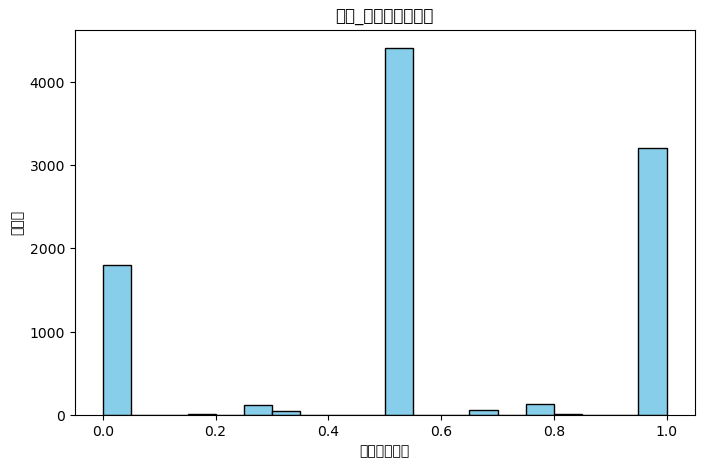

In [438]:
import matplotlib.pyplot as plt
# === 应用到 test ===
test['评价_综合评价'] = test.apply(score_overall, axis=1)

# === 画分布图 ===
plt.figure(figsize=(8,5))
plt.hist(test['评价_综合评价'], bins=20, color='skyblue', edgecolor='black')
plt.title('评价_综合评价分布图')
plt.xlabel('综合评价分数')
plt.ylabel('样本数')
plt.show()

In [439]:
# test = test.loc[:, ~test.T.duplicated()]
test.sample(100)
test.to_csv('test_rent_preview.csv', index=False)  # 或者 test.to_excel('test_preview.xlsx', index=False)

### 离群值、插值

In [440]:
# 读取 CSV 文件
test_preview = pd.read_csv('test_rent_preview.csv')

In [441]:
# 删除所有object类型列
test_preview = test_preview.drop(columns=test_preview.select_dtypes(include=['object']).columns)
# 将 test_preview 中所有非 object 类型的列转换为 float
test_preview = test_preview.astype({col: 'float' for col in test_preview.columns if test_preview[col].dtype != 'O'})
test_preview.sample(10)

,ID,城市,面积,lon,lat,年份,区县,板块,房屋总数,楼栋总数,...,是否有气,租期_最小,租期_最大,租期_中值,配套_数量,付款_季付价,付款_年付价,付款_月付价,是否整租,评价_综合评价
5408,2005408.0,4.0,93.80,122.697777,32.039636,2022.0,80.0,523.0,1269.0,193.0,...,1.0,NaN,NaN,NaN,3.0,1.0,0.0,0.0,1.0,0.500000
9689,2009689.0,3.0,97.00,122.109400,32.382179,2022.0,64.0,954.0,9342.0,68.0,...,1.0,12.0,12.0,12.0,9.0,1.0,0.0,0.0,1.0,0.166667
1056,2001056.0,0.0,70.00,117.445864,40.860943,2022.0,7.0,1015.0,1280.0,10.0,...,1.0,7.0,12.0,9.0,8.0,1.0,0.0,0.0,1.0,0.000000
9005,2009005.0,0.0,56.73,117.528429,40.988524,2022.0,68.0,1034.0,642.0,10.0,...,1.0,12.0,12.0,12.0,7.0,1.0,0.0,0.0,1.0,0.500000
8339,2008339.0,3.0,80.00,121.632698,32.214388,2022.0,20.0,1017.0,2135.0,56.0,...,1.0,12.0,12.0,12.0,6.0,1.0,0.0,0.0,1.0,1.000000
8401,2008401.0,10.0,66.00,114.580590,23.805238,2022.0,17.0,1045.0,3983.0,8.0,...,1.0,NaN,NaN,NaN,5.0,0.0,0.0,1.0,1.0,1.000000
52,2000052.0,7.0,37.00,115.174711,23.591527,2022.0,102.0,458.0,1841.0,5.0,...,1.0,6.0,8.0,7.0,7.0,0.0,0.0,1.0,1.0,1.000000
4151,2004151.0,7.0,89.60,115.223211,23.657142,2022.0,131.0,633.0,1065.0,9.0,...,1.0,NaN,NaN,NaN,7.0,0.0,0.0,1.0,1.0,1.000000
769,2000769.0,6.0,45.00,115.928631,41.802608,2023.0,71.0,616.0,138.0,4.0,...,1.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.000000
948,2000948.0,0.0,125.25,117.466491,41.094938,2022.0,65.0,379.0,6617.0,45.0,...,1.0,NaN,NaN,NaN,8.0,1.0,0.0,0.0,1.0,1.000000


In [442]:
for col, dtype in zip(test_preview.columns, test_preview.dtypes):
    print(col, dtype)

ID float64
城市 float64
面积 float64
lon float64
lat float64
年份 float64
区县 float64
板块 float64
房屋总数 float64
楼栋总数 float64
绿化率 float64
容积率 float64
停车位 float64
coord_x float64
coord_y float64
户型_室 float64
户型_厅 float64
户型_卫 float64
总共楼层 float64
楼层_高楼层 float64
楼层_中楼层 float64
楼层_低楼层 float64
楼层_地下室 float64
朝向_东 float64
朝向_南 float64
朝向_西 float64
朝向_北 float64
楼型_塔楼 float64
楼型_塔板结合 float64
楼型_板楼 float64
楼型_平房 float64
是否有装修 float64
有无电梯 float64
交易_年 float64
交易_月 float64
交易_日 float64
建筑年份 float64
建筑物龄期 float64
物业费_最小 float64
物业费_最大 float64
物业费_均值 float64
产权_商品房类 float64
产权_经济适用房类 float64
产权_安置房类 float64
产权_公房类 float64
产权_私产类 float64
产权_其他类 float64
供暖_集中供暖 float64
供暖_自采暖 float64
供暖_无供暖 float64
燃气费_最小 float64
燃气费_最大 float64
燃气费_均值 float64
供热费_最小 float64
供热费_最大 float64
供热费_均值 float64
停车费_最小 float64
停车费_最大 float64
停车费_均值 float64
环线_内环范围 float64
环线_中环至外环范围 float64
环线_外环范围 float64
是否民水 float64
是否民电 float64
是否有气 float64
租期_最小 float64
租期_最大 float64
租期_中值 float64
配套_数量 float64
付款_季付价 float64
付款_年付价 float64
付款_月

In [443]:
# 计算每一列缺失值的比例
missing_percentage = test_preview.isnull().mean() * 100

# 输出缺失值比例大于 35% 的列
high_missing_columns = missing_percentage[missing_percentage > 35]
print(f"缺失值超过35%的列:\n{high_missing_columns}")

# 删除这些列
# test_preview = test_preview.drop(columns=high_missing_columns.index)  # 确保删除的是正确的列

# 输出处理后的数据集
print(test_preview.sample(10))

缺失值超过35%的列:
供暖_集中供暖    78.481531
供暖_自采暖     82.195846
供暖_无供暖     98.342372
供热费_最小     72.178451
供热费_最大     72.178451
供热费_均值     72.178451
租期_最小      54.149187
租期_最大      54.149187
租期_中值      54.149187
dtype: float64
             ID    城市      面积         lon        lat      年份     区县     板块  \
4886  2004886.0   4.0   39.58  122.415231  32.014231  2022.0  120.0  900.0   
3202  2003202.0  10.0   97.00  114.613428  23.810952  2022.0    NaN    NaN   
8067  2008067.0   3.0   89.00  122.118366  32.313204  2022.0   64.0  921.0   
6812  2006812.0   3.0  105.00  122.017862  32.458280  2023.0   64.0  277.0   
3603  2003603.0   2.0  100.00  107.323421  30.608017  2022.0   78.0  349.0   
4981  2004981.0   0.0   50.00  117.222882  40.747730  2022.0   62.0  911.0   
4299  2004299.0   3.0  132.00  121.971005  32.294824  2022.0   64.0  491.0   
7172  2007172.0   3.0   93.00  122.006046  32.347187  2022.0   64.0  769.0   
7794  2007794.0   3.0   60.00  122.161173  32.460206  2023.0   33.0  322.0   
5382

In [444]:
# 输出缺失值比例小于 20% 的列
low_missing_columns = missing_percentage[missing_percentage <= 20]
low_missing_columns

ID            0.000000
城市            0.000000
面积            0.000000
lon           0.000000
lat           0.000000
年份            0.000000
区县            9.464852
板块            9.577407
房屋总数          9.444388
楼栋总数          9.444388
coord_x       9.444388
coord_y       9.444388
户型_室          0.000000
户型_厅          0.000000
户型_卫          0.000000
总共楼层          0.000000
楼层_高楼层        0.000000
楼层_中楼层        0.000000
楼层_低楼层        0.000000
楼层_地下室        0.000000
朝向_东          0.000000
朝向_南          0.000000
朝向_西          0.000000
朝向_北          0.000000
是否有装修         0.000000
有无电梯          0.000000
交易_年          0.000000
交易_月          0.000000
交易_日          0.000000
产权_商品房类       0.000000
产权_经济适用房类     0.000000
产权_安置房类       0.000000
产权_公房类        0.000000
产权_私产类        0.000000
产权_其他类        0.000000
环线_内环范围       0.000000
环线_中环至外环范围    0.000000
环线_外环范围       0.000000
是否有气          6.047273
配套_数量         0.000000
付款_季付价        0.000000
付款_年付价        0.000000
付款_月付价        0.000000
是否整租       

## 特征工程

In [445]:
import pandas as pd
import numpy as np

# 需要处理的数值列（保持你给出的顺序，可增减）
num_cols = [
    "租期_最小", "租期_最大", "租期_中值",
    "总共楼层", "物业费_最小", "物业费_最大", "物业费_均值",
    "停车位", "停车费_最小", "停车费_最大", "停车费_均值",
    "容积率", "燃气费_最小", "燃气费_最大", "燃气费_均值",
    "评价_综合评价", "年份", "面积", "绿化率", "楼栋总数", 
    "交易_年", "建筑物龄期", "建筑年份", "户型_卫", "户型_厅", "户型_室",
    "供热费_最小", "供热费_最大", "供热费_均值", "房屋总数"
]

# 确保这些列都在 test 里
num_cols = [c for c in num_cols if c in test.columns]

def clip_outliers_iqr(df, cols, k=1.5):
    """
    用 IQR 法把异常值缩到 [Q1-k*IQR, Q3+k*IQR]，不删样本。
    """
    df = df.copy()
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        df[col] = df[col].clip(lower=lower, upper=upper)
    return df

# 原地覆盖，保持原名
test = clip_outliers_iqr(test, num_cols)
test.to_csv('test_rent_preview.csv')